# 05 — Retrieval: BM25 vs Dense (E2 + E3, T3.4/T3.6/T3.7/T3.8)

Story notebook for Milestone 3's retrieval work (PLAN.md §3 E2/E3, RQ2).
Thin (PLAN.md §6): every table and figure below was already produced by
earlier tasks — this notebook only loads and displays them, plus renders
one live table (`h2_interaction_summary`) from already-computed scores.
No corpus load, no index build, no GPU needed to run this notebook.

**Sources:**
- E2 chunking study — `notebooks/04_chunking_study.ipynb` (T3.4)
- E3 RQ2 eval — `src/cragb/eval/run_retrieval_eval.py --mode eval` (T3.6)
- Per-type breakdown — `--mode by-type` (T3.7)
- Win/loss examples — `--mode winloss` + `reports/retrieval_winloss_examples.md` (T3.8)

In [1]:
import pandas as pd
from IPython.display import Image, Markdown, display

from cragb.eval.run_retrieval_eval import h2_interaction_summary
from cragb.utils.io import resolve_path

pd.set_option("display.width", 120)

## E2 — Chunking study recap (T3.4)

Full analysis in `notebooks/04_chunking_study.ipynb`; reproduced here for
context since RQ2 below is evaluated under the scheme this study locked in.

,scheme,k,recall_mean,recall_ci_lo,recall_ci_hi,n_questions
0,whole_review,1,0.058728,0.044565,0.077956,58
1,whole_review,3,0.153651,0.132762,0.175516,58
2,whole_review,5,0.260243,0.230581,0.290571,58
3,whole_review,10,0.503915,0.456889,0.551506,58
4,fixed_token_128,1,0.046182,0.037224,0.055433,58
5,fixed_token_128,3,0.140015,0.108615,0.180737,58
6,fixed_token_128,5,0.223779,0.189716,0.264755,58
7,fixed_token_128,10,0.425103,0.377092,0.473115,58
8,fixed_token_256,1,0.058728,0.044659,0.078776,58
9,fixed_token_256,3,0.151019,0.129968,0.173223,58


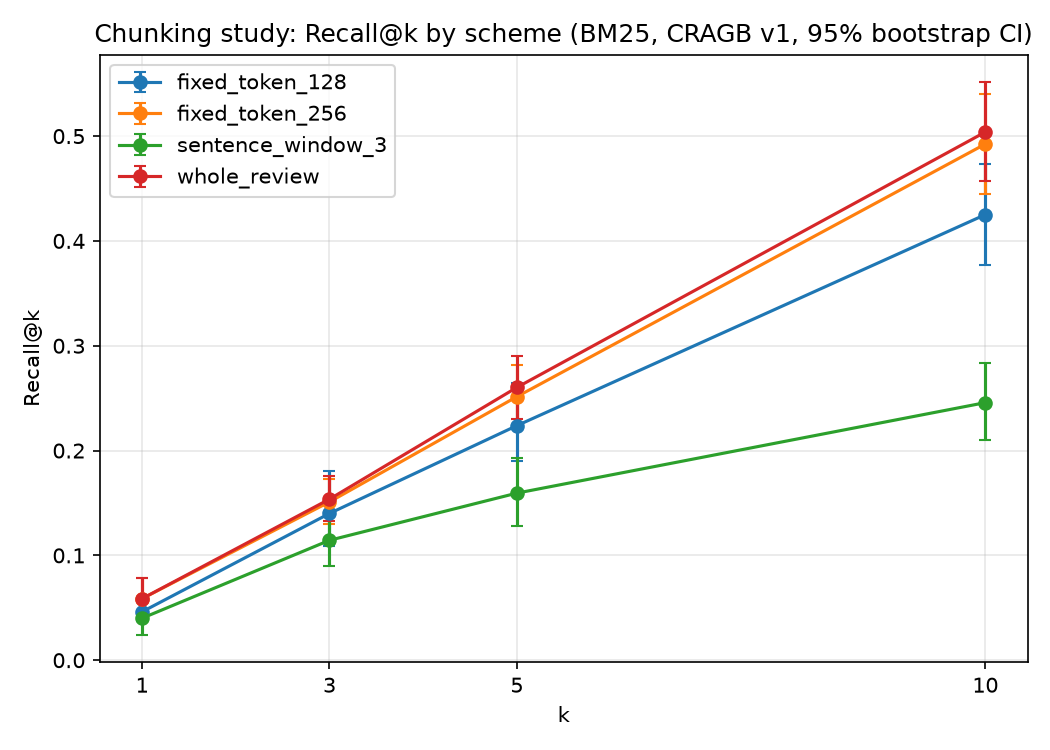

In [2]:
chunking_table = pd.read_csv(resolve_path("results/tables/chunking_study_v1.csv"))
display(chunking_table)
display(Image(filename=str(resolve_path("reports/figures/chunking_recall.png"))))

**Verdict:** `whole_review` wins Recall@k at every k, though it's statistically
indistinguishable from `fixed_token_256` (only ~2.7% of reviews exceed 256
tokens). `sentence_window_3` is the clear loser — fragmenting short reviews
into 3-sentence windows breaks apart the exact keyword co-occurrences BM25
relies on. `configs/chunking.yaml` is locked to `whole_review`; every result
below is evaluated under that scheme.

## E3 — RQ2: BM25 vs dense, overall (T3.6)

All 58 scorable CRAGB v1 questions, both retrievers, Recall/Hit/nDCG/MRR at
k ∈ {1, 3, 5, 10} with 95% bootstrap CIs and a paired Wilcoxon significance
test between BM25 and dense at each k (questions are the paired unit).

,retriever,k,n_questions,recall_mean,recall_ci_lo,recall_ci_hi,hit_mean,hit_ci_lo,hit_ci_hi,ndcg_mean,ndcg_ci_lo,ndcg_ci_hi,mrr_mean,mrr_ci_lo,mrr_ci_hi,recall_wilcoxon_p,hit_wilcoxon_p,ndcg_wilcoxon_p,mrr_wilcoxon_p
0,bm25,1,58,0.058728,0.044565,0.077956,0.793103,0.689655,0.896552,0.793103,0.689655,0.896552,0.793103,0.689655,0.896552,0.512442,0.738883,0.738883,0.738883
1,dense,1,58,0.054968,0.041629,0.074553,0.775862,0.672414,0.879310,0.775862,0.655172,0.879310,0.775862,0.672414,0.879310,0.512442,0.738883,0.738883,0.738883
2,bm25,3,58,0.153651,0.132540,0.175634,0.879310,0.793103,0.948276,0.764087,0.671014,0.849932,0.830460,0.735632,0.913793,0.903087,0.527089,1.000000,0.567269
3,dense,3,58,0.152843,0.128760,0.178859,0.844828,0.741379,0.931034,0.742981,0.643394,0.836233,0.801724,0.704023,0.896552,0.903087,0.527089,1.000000,0.567269
4,bm25,5,58,0.260243,0.230642,0.291382,0.931034,0.862069,0.982759,0.760829,0.677258,0.835616,0.840805,0.754598,0.920690,0.971237,0.479500,0.816287,0.585788
5,dense,5,58,0.259141,0.223666,0.299756,0.896552,0.810345,0.965517,0.750701,0.659755,0.836349,0.814655,0.718391,0.902299,0.971237,0.479500,0.816287,0.585788
6,bm25,10,58,0.503915,0.454927,0.550583,0.948276,0.879310,1.000000,0.764075,0.686834,0.835877,0.842720,0.754789,0.920699,0.399902,0.654721,0.480152,0.669510
7,dense,10,58,0.527882,0.484261,0.572320,0.965517,0.913793,1.000000,0.773860,0.700121,0.844678,0.823515,0.733950,0.905172,0.399902,0.654721,0.480152,0.669510


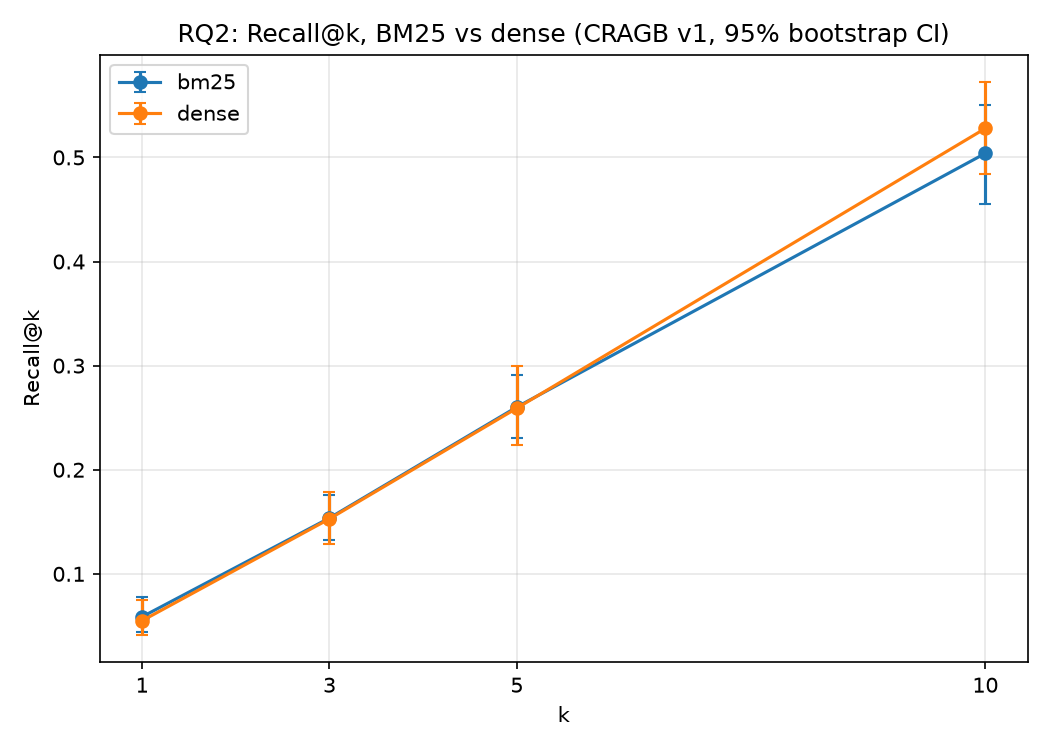

In [3]:
rq2_table = pd.read_csv(resolve_path("results/tables/retrieval_eval_v1.csv"))
display(rq2_table)
display(Image(filename=str(resolve_path("reports/figures/recall_at_k_bm25_vs_dense.png"))))

**Finding: no significant difference at any k.** Every `*_wilcoxon_p` value
in the table above is well over 0.05, and every CI heavily overlaps. BM25
edges ahead at k∈{1,3,5}; dense edges ahead at k=10 — neither difference is
distinguishable from noise at n=58. This matches PLAN.md's own H2 framing:
*"expect a query-type interaction, not a global winner"* — which is exactly
why the per-type breakdown below is the more interesting result.

## Per-question-type breakdown — the H2 interaction (T3.7)

Slices the same scores by CRAGB's question `type` at k=5, to test whether
dense wins paraphrased/semantic questions and BM25 wins lexical/attribute
questions, even though neither wins overall.

,retriever,type,k,recall_mean,recall_ci_lo,recall_ci_hi,n_questions
0,bm25,colour_appearance,5,0.300843,0.174107,0.439732,8
1,dense,colour_appearance,5,0.174603,0.088542,0.257440,8
2,bm25,defects,5,0.158682,0.092063,0.217191,7
3,dense,defects,5,0.429884,0.288340,0.632832,7
4,bm25,durability,5,0.314692,0.255606,0.384658,8
5,dense,durability,5,0.198440,0.103045,0.269357,8
6,bm25,fabric_quality,5,0.280536,0.238286,0.341652,9
7,dense,fabric_quality,5,0.278372,0.231814,0.340570,9
8,bm25,fit_sizing,5,0.275093,0.245366,0.320436,12
9,dense,fit_sizing,5,0.239837,0.190952,0.272539,12


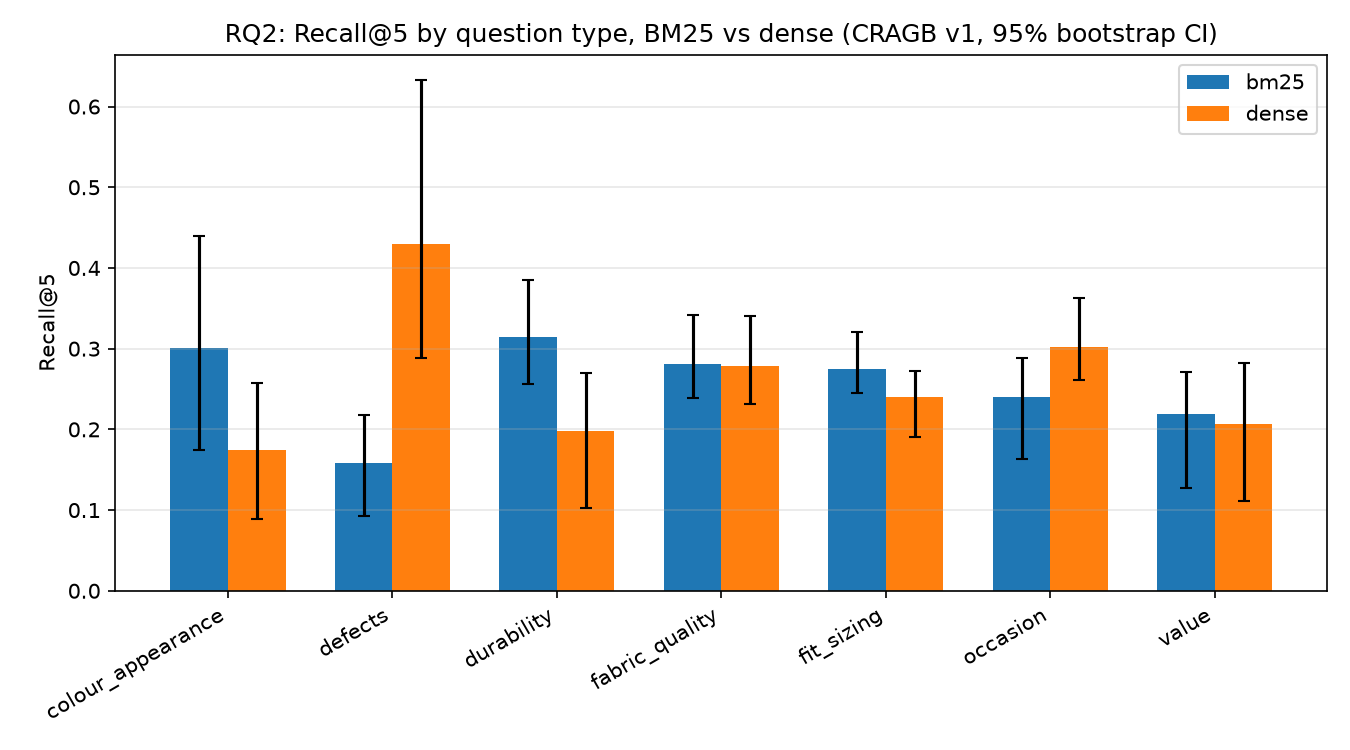

retriever,type,bm25_recall_mean,dense_recall_mean,leader
0,colour_appearance,0.300843,0.174603,bm25
1,defects,0.158682,0.429884,dense
2,durability,0.314692,0.198440,bm25
3,fabric_quality,0.280536,0.278372,bm25
4,fit_sizing,0.275093,0.239837,bm25
5,occasion,0.239696,0.301737,dense
6,value,0.219256,0.206558,bm25


In [4]:
by_type_table = pd.read_csv(resolve_path("results/tables/retrieval_eval_by_type_v1.csv"))
display(by_type_table)
display(Image(filename=str(resolve_path("reports/figures/recall_per_type.png"))))

h2_summary = h2_interaction_summary(by_type_table)
display(h2_summary)

**Finding: a real interaction.** BM25 leads on 5 of 7 question types
(colour_appearance, durability, fabric_quality, fit_sizing, value); dense
clearly leads on `defects` (0.43 vs 0.16 Recall@5) and slightly leads on
`occasion`. No single retriever wins everywhere — the type-level breakdown
is where the interesting result actually lives, since the overall T3.6
comparison was a near-exact tie.

## Qualitative win/loss examples (T3.8 appendix)

The 8 most lopsided BM25-wins / dense-wins questions at k=5 (4 each way),
with each retriever's real top-5 hits and a one-line explanation of why one
retriever won — written after reading the actual retrieved text below, not
auto-generated. Full detail: `reports/retrieval_winloss_examples.md`.

In [5]:
winloss_md = resolve_path("reports/retrieval_winloss_examples.md").read_text(encoding="utf-8")
display(Markdown(winloss_md))

# Retrieval win/loss examples (T3.8; PLAN.md §7 appendix)

Questions where BM25 and dense retrieval disagreed sharply on Recall@5 (CRAGB v1). ✅ marks a hit that is actually in the question's pooled `relevant_ids`; ❌ marks a hit that is not.

## BM25 wins, dense loses

### `colour_appearance_006` (colour_appearance)
**Q:** Are there any reviews that discuss how the product's color changes in different lighting conditions?

Recall@5: BM25=0.67, dense=0.00 — gold relevant ids: 47004, 61018, 75274, 102131, 107528, 171235

**BM25 top-5:**
- ✅ `171235` (score 26.944): Beautiful, delicate necklace and chain. Light, airy. The stones (says they're real) sparkle nicely in different lighting conditions. The chain is the right length to show off this gorgeous trinity kno
- ✅ `61018` (score 23.077): I ordered these earrings because I was attracted to the mosaic colors. They came nicely packaged with a soft cloth. They appear substantial and well made. Unfortunately, I was disappointed in the lack
- ❌ `124005` (score 22.669): This is a great headband. The color I received looks like pink lemonade. The fabric is very soft and won't damage hair in any way. It's ideal for curly hair. There are instructions included that tell 
- ✅ `75274` (score 21.522): This tie changes character in different lighting in a very nice way, from midnight to baby blue with just the right sheen. The textures are detailed and evident but not jumping off the tie. Material s
- ✅ `47004` (score 21.454): I have the “Ice Blue Beads” color of the Alex and Ani Splendid Beaded Expandable Bangle. I like this color because it looks different depending on how the light hits it. Under natural lighting, the be

**Dense top-5:**
- ❌ `186910` (score 0.756): I bought 2. A darker/brighter on and a softer colored one. It is a lighter shade in pastels to the brighter colored one. I thought they were patterned differently. The pictures showed them folded or d
- ❌ `167340` (score 0.750): Product is excellent, but the colors come alittle bit different from advertised!
- ❌ `169256` (score 0.747): Definitely, color is an issue should have waited and purchased the lighter neutral color. Will wait for colder weather for a more comprehensive review.
- ❌ `22288` (score 0.745): It's aight. Not what I thought it was gone be. Ion be out at night so want get to enjoy color changing.
- ❌ `197015` (score 0.735): I do like the product overall but I am extremely disappointed with the actual color. I purchased the pink and turquoise set. The blue isn’t vivid at all (as depicted in the pictures). Instead it’s a d

**Why:** BM25 matched the literal phrase “different lighting conditions” appearing almost verbatim in 4 of its top-5 reviews; dense's nearest neighbors were generic color-disappointment reviews that never mention lighting at all, so it missed the lighting-specific angle entirely.

### `colour_appearance_neg_000` (colour_appearance)
**Q:** Does the dye lot number affect the shade of colour received?

Recall@5: BM25=0.50, dense=0.00 — gold relevant ids: 28047, 134904

**BM25 top-5:**
- ❌ `83691` (score 26.773): It does fit but the colour is completely different from the picture here it is a lot more fuschia and almost neon colour like orange even not flattering at all. Not wearing this probably ever, maybe j
- ❌ `90174` (score 26.652): These are very nice and long. I love the vivid colour. The only thing I didn't care for was the strong odor, which I'm sure was the dye. The smell did wash out.
- ❌ `105003` (score 25.668): These area so very comfortable and fits very nicely. No toe pinch or rub. TBN the colour in my picture is different than the stock picture, however the colour of the shoe is exactly as pictured in the
- ❌ `3036` (score 25.653): Received the wrong colour twice from the seller, so I returned them both. Had I not been keen on the colour sent to me, I would have kept them. They are incredibly squishy and soft.
- ✅ `28047` (score 25.045): One shoe changes colour more than the other does.

**Dense top-5:**
- ❌ `191558` (score 0.733): Buying a bunch if colors.
- ❌ `7610` (score 0.731): rings changed colors
- ❌ `63699` (score 0.730): I purchased 3 packages of 8 panties. I was sent packages containing three panties. While the total number sent is correct, this is not what I ordered. In a package of 8 there will be a greater variety
- ❌ `167340` (score 0.728): Product is excellent, but the colors come alittle bit different from advertised!
- ❌ `119078` (score 0.728): Does not file as expected but nice color

**Why:** BM25's heavy weighting on “colour”/“dye” surfaced one genuinely relevant review (a shoe's dye lot varying between the two feet) purely on term overlap; dense clustered around generic “wrong color than expected” complaints and missed the dye-lot-specific review.

### `fit_sizing_neg_000` (fit_sizing)
**Q:** Do buyers report the exact chest measurement in inches for the size medium?

Recall@5: BM25=0.50, dense=0.00 — gold relevant ids: 47706, 110475, 116514, 125710

**BM25 top-5:**
- ❌ `41628` (score 30.129): The fit is really off. The body is slightly fitted. The chest measurement on a large is 21 inches. The sleeve opening is too wide. It measures 7 1/2 inches on the large. You need Popeye arms for this 
- ❌ `17016` (score 27.895): This lounge undershirt from ATTI TUDE is very soft. It makes a great base layer or a comfortable shirt to wear around the house and to bed. The modal fabric sort of hugs your body, so the shirt moves 
- ✅ `116514` (score 26.956): This base layer set comes in a nylon zipper pouch that you could reuse to keep the set in a backpack or to pack it down for traveling. When I took the set out of the pouch, I was worried the shirt and
- ❌ `37161` (score 26.734): The sizing information in the product listing is completely wrong. I normally wear a 44L jacket. The second picture in the product listing indicates that for size XL, chest is 50.8 inches, length is 2
- ✅ `47706` (score 26.694): First of all, I love the lingerie set. The lace material isn't a bother and it compliments the body quite well. I did order the medium size and the fit was a bit on the loose side. Most likely going t

**Dense top-5:**
- ❌ `12416` (score 0.767): Bought a medium within the specified chest dimension , what I got is way too small, you would have to be severely anorexic to fit in it
- ❌ `52525` (score 0.757): I order an x-large and I believe it was miss labeled and it was a medium. The refund process was great.
- ❌ `33401` (score 0.747): Falsifying the size it didn’t measure what it says on the website
- ❌ `176528` (score 0.738): I received the correct size however it was WAY smaller than advertised
- ❌ `68453` (score 0.737): I'm a 34 and it says I should purchase Mediums, so I did. They're too small.

**Why:** BM25's exact match on “chest”/“measurement”/“inches” found reviews that literally cite numeric measurements; dense's notion of “size complaint” pulled generic “ran small” reviews with no numbers in them at all, missing what the question actually asked for.

### `durability_neg_000` (durability)
**Q:** How many wash cycles on average does the product survive under controlled lab testing?

Recall@5: BM25=0.50, dense=0.00 — gold relevant ids: 78415, 93761, 121719, 187723

**BM25 top-5:**
- ❌ `191398` (score 24.634): This product did not survive a single washing. Threads through the waist unraveled and garroted other clothes in the wash.
- ❌ `147473` (score 21.362): These socks are super comfortable! They are perfect for wearing around the house during the winter. The creatures are so cute and adorable. The socks also fit perfectly and can survive many washes. I 
- ✅ `78415` (score 20.310): Authentic Pigment makes the absolute best t shirts. No fade whatsoever for about 50 wash cycles.
- ❌ `150901` (score 19.645): The fit is good - not too baggy or restrictive. the support is average. very soft to touch, no riding up or bunching. seems to more breathable than Reebok, Columbia and Champion (though I like the Cha
- ✅ `93761` (score 18.633): They fit well and arrived quickly, I wash in cold water and the blue one still looks good, but the black is noticably faded after less than 10 cycles.

**Dense top-5:**
- ❌ `3896` (score 0.721): We will see how long they last after washing them for 3 to 6 months
- ❌ `55127` (score 0.719): Holding up well after multiple washings.
- ❌ `27799` (score 0.719): Holding up well after multiple washings.
- ❌ `119035` (score 0.716): Hold up well in the wash
- ❌ `65553` (score 0.713): So far it’s washed well and held up

**Why:** BM25 found reviews using the near-literal phrase “wash cycles” with an attached count (“50 wash cycles”, “less than 10 cycles”); dense retrieved topically-similar “holds up after washing” reviews, but none of its top-5 actually state a cycle count.

## Dense wins, BM25 loses

### `defects_neg_001` (defects)
**Q:** Do buyers report the specific factory batch number associated with defective units?

Recall@5: BM25=0.00, dense=1.00 — gold relevant ids: 117931

**BM25 top-5:**
- ❌ `182748` (score 19.413): Defective, it has a large 8&#34; faded ring all the way around the top of the Beret. Why do we keep receiving defective merchandise !
- ❌ `110899` (score 18.700): The sheepskin inside one of the slippers is defective. It is clumped, with a ball of clump, and misshapen. This is now the second defective pair I received. I will not trying a third. I do not recomme
- ❌ `17998` (score 17.736): Socks with non slip properties, but not the best, but neither the worst. Sorry for the inconclusive report, it is just that they do not excelled, neither fail in their anti skid duties.
- ❌ `117466` (score 17.678): Really disappointed with the appearance of the Firelily in black leather. As another reviewer mentioned, the front of the shoes looks scuffed. The overall pattern seems flawed in the front of both sho
- ❌ `175995` (score 17.484): I like the soft feel of the bangle and tassels though it is large and impractical for a key ring unless it was for a specific purpose, like laundry room keys, etc. The fringed tassel is perfect though

**Dense top-5:**
- ❌ `20772` (score 0.708): Wrong measurement from Factory
- ❌ `131204` (score 0.708): I’ve purchased many 505s in the past but these seem to have been mislabeled
- ❌ `193820` (score 0.701): Just cannot seem to trust whether these are counterfeit, defective, factory 2nds, or actual Levi's anymore. My Levi's when ordered online too often have flaws: improper fit, bad zipper, 5 belt loops i
- ✅ `117931` (score 0.690): I ordered these twice. The first one was give N go as advertised. When the second batch arrived it was labeled give N go 2.0. The 2.0 according to other reviews has not had a good rating. I like the o
- ❌ `147902` (score 0.689): Ordered small and shipped large. Although Amazon shipped the correct produce, I retain the negative review as I have recently received 2 wrong products and 1 that didn't work. This is not the Amazon I

**Why:** Dense's one relevant hit is only a loose semantic reach (a review mentioning a product's appended version number, not literally a factory batch number) — still enough to edge out BM25, whose top-5 all keyword-matched “defective” broadly without touching batch/version numbering at all.

### `occasion_neg_000` (occasion)
**Q:** Is this item officially licensed or endorsed for use at professional sporting events?

Recall@5: BM25=0.00, dense=0.50 — gold relevant ids: 83107, 173986

**BM25 top-5:**
- ❌ `120269` (score 23.045): Love this top! I typically wear it to sporting events or just running around doing errands. It's comfy & fits well.
- ❌ `26122` (score 20.205): Good quality for the price. Works well for stadium, concert and sporting events. Just the right size for small wallet, cell phone & sunglasses.
- ❌ `44057` (score 20.076): I love to use tote bags and this one is really cute! I like the see through quality of it. While the product description says that this can be used for sporting events, it's too large for most of the 
- ❌ `76910` (score 16.990): What's not to love?<br />It's a belt with a bear on the buckle, holds your pants or trousers up (sparing you embarrassment of possibly being bear back, bad pun, but I had to), the price is reasonable 
- ❌ `19384` (score 16.721): I was very pleased with this product. The material is thick, high quality, and felt like a professional chef. It was comfortable to wear all day while I made Thanksgiving dinner. Made for a great memo

**Dense top-5:**
- ❌ `106505` (score 0.707): Its good for going to sporting events. They won't let any bag that isn't clear. I can fit a jacket and some smaller stuff in there. It's pretty cheap though. The rope already came untied after a few u
- ❌ `135939` (score 0.685): Since public venues are now so security conscious, I was looking for a clear tote bag to use should we ever go to a baseball game or large event where clear bags are required. This is made of a nice h
- ✅ `173986` (score 0.682): Counterfeit item not really FOX Racing
- ❌ `163660` (score 0.681): This product was perfect for my athletes. Baseball and football players and they loved it. Great value for the money.
- ❌ `177203` (score 0.680): I use this bag for stadium use. It is clear so they can see what is inside.

**Why:** Dense surfaced a review calling the item “counterfeit, not really [brand]” — a real semantic link to “not officially licensed” with zero shared vocabulary with the question; BM25 matched the literal phrase “sporting events” but only found reviews about using the product at events, not about licensing or endorsement.

### `defects_005` (defects)
**Q:** Are there any complaints about defects or damage to the packaging?

Recall@5: BM25=0.10, dense=0.50 — gold relevant ids: 3574, 42696, 57010, 65646, 74543, 125294, 140332, 150678, 164069, 171382

**BM25 top-5:**
- ❌ `114050` (score 19.541): After replacing the first pair (the right boot squeaked relentlessly) I now have a functional pair of these boots. There was no hassle or complaints about the exchange. The boots I currently have are 
- ❌ `90760` (score 19.309): Super cute and comfy! They seem true to size (it's hard to find a 10.5 so I'm happy about that)<br />The only complaint I have is the mildew on the boots, I mean... WTH?? It cleaned up just fine thoug
- ❌ `193494` (score 19.234): sturdy and pretty but some black keys are scratched or faded. the lid covers the defects, though.
- ❌ `66445` (score 18.584): Favorite brand of shoe. I can generally always count on their fit. I have and have had a least a dozen pairs of different styles over the years. Ordered the 8.5 2E. They fit perfectly. Comfy. I have w
- ✅ `57010` (score 18.296): Product works as intended, but nothing about the product or packaging was too interesting

**Dense top-5:**
- ✅ `171382` (score 0.766): Produced arrived cracked even though box seemed fine.
- ✅ `125294` (score 0.761): The product itself is not bad. It keeps my ear warm even when the weather is below 0 Fahrenheit. However, the packaging needs extra work to be good. It looked like used when it arrived and that shaken
- ✅ `3574` (score 0.759): Item pretty decent, as expected but packaging....not sure. Is this how it’s supposed to be or has this been repacked? Used and returned item???
- ✅ `140332` (score 0.759): We open the package with a glue on it. Damaged before use
- ✅ `150678` (score 0.755): OK, a little cheaply made and box had some damage, but item was not damaged

**Why:** Dense's embedding captured “packaging damage” as a coherent semantic cluster — 4 of its top-5 hits are directly about damaged/suspicious packaging; BM25's top hits matched “defect”/“complaint” generically (boots, general quality gripes) and mostly missed the packaging-specific angle, since “packaging” itself wasn't a dominant term in most of the actually-relevant reviews.

### `colour_appearance_010` (colour_appearance)
**Q:** Do reviewers mention any issues with the color being uneven or inconsistent?

Recall@5: BM25=0.00, dense=0.33 — gold relevant ids: 59714, 69704, 195703

**BM25 top-5:**
- ❌ `105388` (score 22.779): I agree with other reviewers that the sizing on these shoes is inconsistent. I ordered 2 pairs, 1 leather and the other canvas. The leather pair fits fine and I am wearing them. The canvas pair in the
- ❌ `85990` (score 22.081): The straps of these shoes are way too wide you practically slip off them if you do any walking on uneven ground or cobbelstones.
- ❌ `11674` (score 21.113): I am a pretty standard medium and these felt more like a small especially in the waist. Otherwise they are well made and comfortable. My recommendation is to size up. Unlike other reviewers, I didn't 
- ❌ `186699` (score 20.965): The shirts are really thin and the graphics are very light, bordering on faded-looking. The hems are uneven, being longer at the sides than front or back. And even though it is listed as having free r
- ❌ `25768` (score 20.896): This hoodie is lightweight and works well for hot weather. It feel soft, comfortable, cool on the skin. I like the fit and feel of the sweatshirt.<br /><br />Other reviewers have flagged issues with t

**Dense top-5:**
- ❌ `113041` (score 0.772): Reviewers seem happy with normal colors…I expected the top to have the color I chose and shiny texture as shown, did not, returned. (Pon?)
- ❌ `169256` (score 0.759): Definitely, color is an issue should have waited and purchased the lighter neutral color. Will wait for colder weather for a more comprehensive review.
- ✅ `195703` (score 0.744): Looks good but it’s fading maybe mine is defective I don’t know
- ❌ `68680` (score 0.741): The quality wasn’t what I was hoping for but the color and size was right.
- ❌ `134096` (score 0.740): The colors didn’t match what I wanted it to

**Why:** BM25 matched “uneven”/“inconsistent” literally, but landed on sizing and hem complaints — a lexical false-positive, since those reviews use the same words for a different topic; dense at least found a loosely related color-fading review (“maybe mine is defective”) that shares no vocabulary with the question but is actually about color.


## Summary

- **E2 (chunking):** whole-review chunking wins on evidence, not assumption — locked into `configs/chunking.yaml`.
- **E3 (RQ2, overall):** BM25 and dense are statistically indistinguishable across all 58 questions at every k — no global winner.
- **E3 (RQ2, by type):** but the tie hides a real interaction — BM25 leads most categories, dense clearly wins on `defects` and edges ahead on `occasion`.
- **Qualitative pattern:** BM25 wins tend to be exact-phrase matches (e.g. "different lighting conditions", "wash cycles", "chest measurement... inches"); dense wins tend to be genuine paraphrases with near-zero lexical overlap (e.g. "counterfeit, not really [brand]" answering an "officially licensed" question). This is the query-type interaction PLAN.md's H2 predicted, now shown with real evidence rather than assumed.